# Lab2 - Active Learning on Streams - Solutions by Łukasz Grzegrzółka

Credits:

- the notebook is originally created by Daniel Kałuża
- modified and extended by Sebastian Stawicki

We will take a look at a data-stream problems and apply an exemplary active learning method for streams.

Stream assumptions:
- we don't know the size of the stream
- in some scenarios it is not feasible to store all of the data
- we cannot process all of the data at once
- the distribution of the data may change over time
- labeling is expensive
- the decision which data to store and label should be made quickly as the data is coming - in real time or shortly after the data is received

An example of data stream with images can found here:
https://randomwordgenerator.com/picture.php


## 0. Imports

In [260]:
import matplotlib.pyplot as plt
import numpy as np

## 1. Prepare a dataset 

We can use an actual data stream or simulate one. During this lab we will use a **Fashion-MNIST** dataset and simulate a stream dataset on it.

The dataset contains grayscale images of clothing items where each image is represented as 784 (28x28 pixels arranged row-wise) integers within the range [0, 255]. The dataset has 10 classes:

Fashion-MNIST has 10 classes:

| Label | Description   |
| ---   | ---           |
| 0     | T-shirt/top   |
| 1     | Trouser       |
| 2     | Pullover      |
| 3     | Dress         |
| 4     | Coat          |
| 5     | Sandal        |
| 6     | Shirt         |
| 7     | Sneaker       |
| 8     | Bag           |
| 9     | Ankle boot    |

In [261]:
from sklearn.datasets import fetch_openml

bunch = fetch_openml("Fashion-MNIST")
X = bunch.data.to_numpy()
y = bunch.target.astype(int).to_numpy()



### Get familiar with the dataset

Investigate the distribution of the classes in the dataset.

**Author**: Han Xiao, Kashif Rasul, Roland Vollgraf  
**Source**: [Zalando Research](https://github.com/zalandoresearch/fashion-mnist)  
**Please cite**: Han Xiao and Kashif Rasul and Roland Vollgraf, Fashion-MNIST: a Novel Image Dataset for Benchmarking Machine Learning Algorithms, arXiv, cs.LG/1708.07747  

Fashion-MNIST is a dataset of Zalando's article images, consisting of a training set of 60,000 examples and a test set of 10,000 examples. Each example is a 28x28 grayscale image, associated with a label from 10 classes. Fashion-MNIST is intended to serve as a direct drop-in replacement for the original MNIST dataset for benchmarking machine learning algorithms. It shares the same image size and structure of training and testing splits. 

Raw data available at: https://github.com/zalandoresearch/fashion-mnist

### Target classes
Each training and test example is assigned to one of the following labels:
Label  Description  
0  T-shirt/top  
1  Trouser  
2  Pullover  
3  Dress  
4  

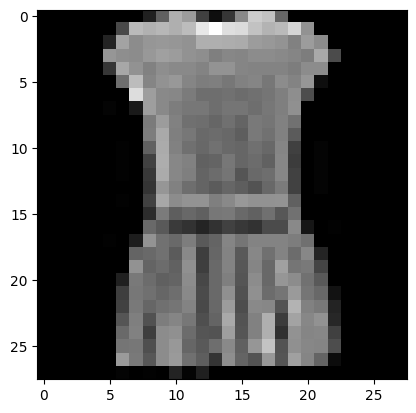

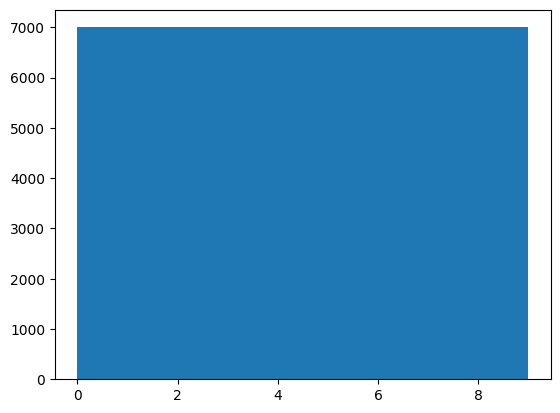

In [262]:
# write your code here
from matplotlib import colormaps

#co to za zbiór danych
print(bunch.DESCR)

#ile jest elementów każdego rodzaju
elements, counts = np.unique(y, return_counts=True)
print(elements)
print(counts)

# pokaż obrazek o danym numerze
plt.imshow(X[3].reshape((28, 28)), cmap='grey')
plt.show()

#histogram
plt.hist(y, bins=10)
plt.show()

In [263]:
print(bunch["url"])

https://www.openml.org/d/40996


### Investigate how the images look like

Implement a function that can display a single image from the dataset. Let the function take also an optional argument that, if provided, will display the actual class name (its string representation) as title of the image.

Use it to visualize a few images, e.g., 10 or so.


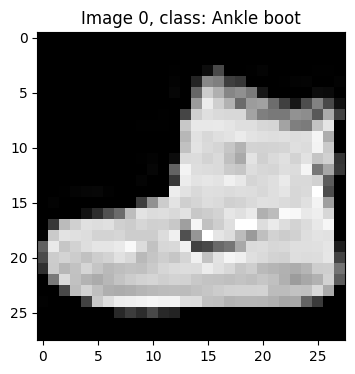

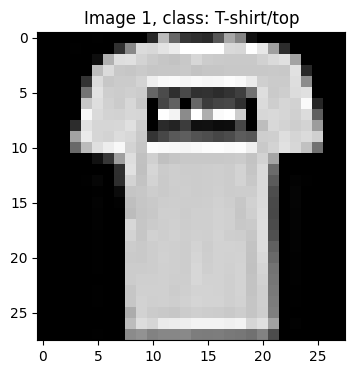

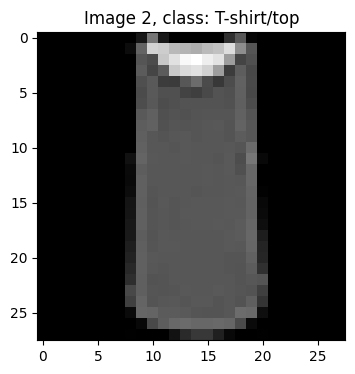

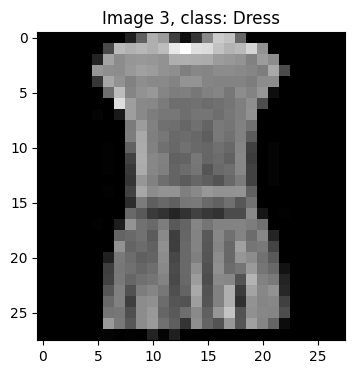

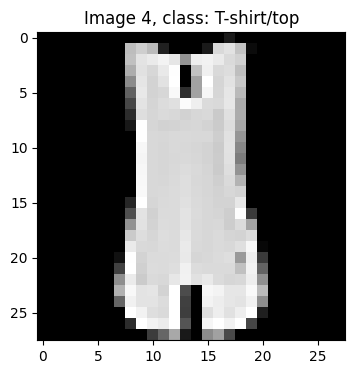

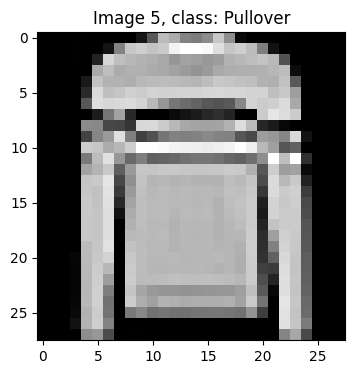

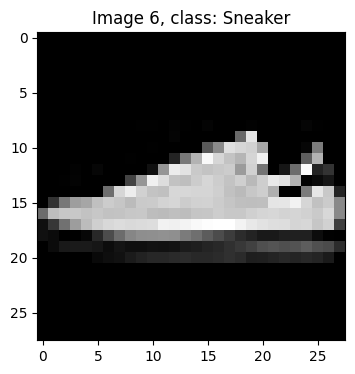

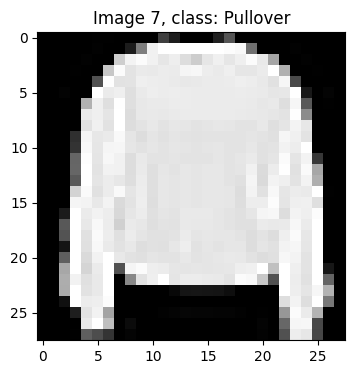

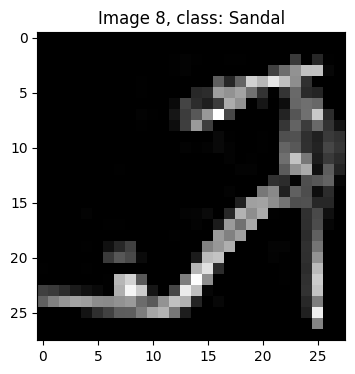

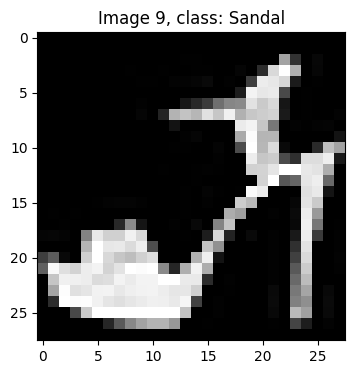

In [264]:
# write your code here

# List of FashionMNIST labels, source: https://github.com/zalandoresearch/fashion-mnist
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

def display(k, print_class_name=False):
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(X[k].reshape((28, 28)), cmap="grey")
    if print_class_name:
        ax.set_title(f"Image {k}, class: {class_names[y[k]]}")
    else:
        ax.set_title(f"Image {k}")
    plt.show()
    return fig, ax

for i in range(10):
    display(i, print_class_name=True)



## 2. Simulate a data stream


### A. Create a small initial training dataset

Draw randomly 0.5% of the data as the initial training dataset (`X_initial, y_initial`). The remaining data will be used for the stream simulation (`X_stream, y_stream`).


In [265]:
# write your code here
from sklearn.model_selection import train_test_split

indices = np.arange(X.shape[0])
idx_initial, idx_stream = train_test_split(indices, train_size=0.005, random_state=42)

X_initial, X_stream = X[idx_initial], X[idx_stream]
y_initial, y_stream = y[idx_initial], y[idx_stream]

### Investigate the initial training dataset

Explore the shape of the initial training dataset and the distribution of the classes in it. 

[0 1 2 3 4 5 6 7 8 9]
[30 40 33 40 30 31 44 40 38 24]


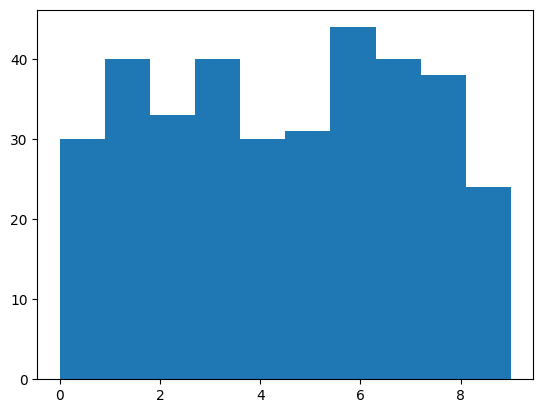

In [266]:
# write your code here
#ile jest elementów każdego rodzaju
elements, counts = np.unique(y_initial, return_counts=True)
print(elements)
print(counts)

plt.hist(y_initial, bins=10)
plt.show()


### B. Create a stream simulation

Use the remaining data (`X_stream, y_stream`) to simulate a stream in a form of a generator function. It should yield a single data point at a time along with its index in the original dataset (so that we can refer to its true label).


In [ ]:
# write your code here
def stream_generator(X_stream, idx_stream):
    for orig_idx, x in zip(idx_stream, X_stream):
        yield orig_idx, x

gen = stream_generator(X_stream, idx_stream)
orig_idx, x = next(gen)
print(orig_idx, x)


46730 [  0   0   0   0   0   0   0   0  36 105 143 165 184 187 169 151 135 121
  86   0   0   0   0   0   0   0   0   0   0   0   0   0   0   3   0  44
 238 237 253 252 249 249 252 254 253 232 248 186   0   0   0   0   0   0
   0   0   0   0   0   0   0   3   0 121 242 211 220 224 253 255 250 231
 215 221 246 244   0   0   1   0   0   0   0   0   0   0   0   0   0   0
   0 162 225 228 241 197  99 111 104 187 253 213 151 161   0   0   0   0
   0   0   0   0   0   0   0   0   0   0  39  75  46  71 162 255 235 134
 252 255 191  38  39  65 114  97   0   0   0   0   0   0   0   0   0   0
   0  83 164  36  57  37  27  80 153  89 151 139  36  57  78  58  86 218
   2   0   0   0   0   0   0   0   0   0   0 159 206  16  61  68  63  44
  31  68  53  32  71  67  73  52  99 241  68   0   0   0   0   0   0   0
   0   0   0 155 223  40  49  68  64  57  66 122 111   3  47  71  75  33
 131 243 136   0   0   0   0   0   0   0   0   0   0 175 230  61  34  67
  61  53 120 115  35   6  62  64  65  27 165 

### Test the stream simulation

Use the generator function and display a few images from the stream.


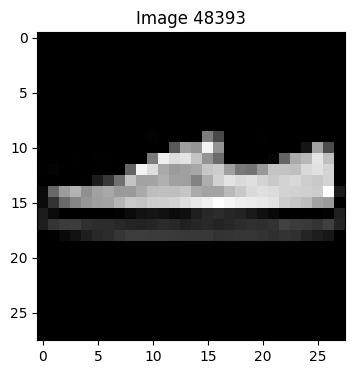

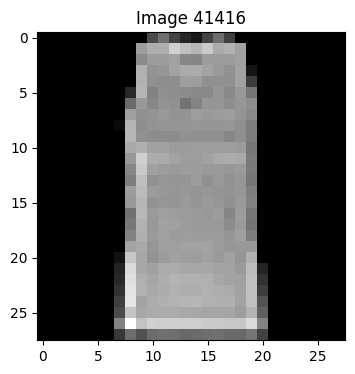

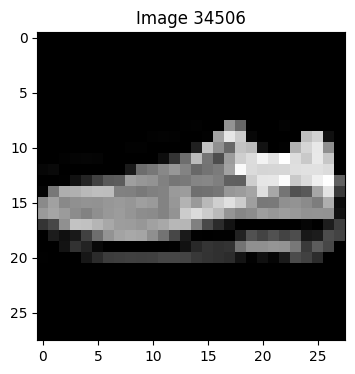

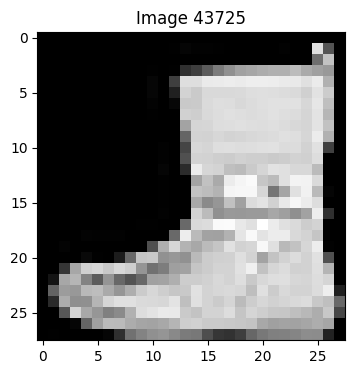

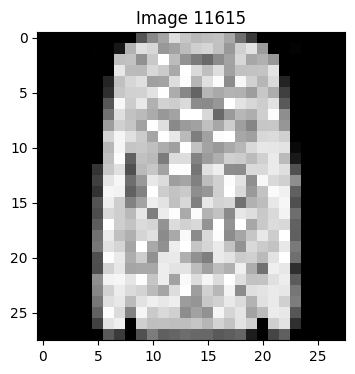

In [268]:
# write your code here
for _ in range(5):
    display(next(gen)[0])


## 3. Prepare models

Train a ridge classifier model on the initial training dataset. Scale the data before training the model.


In [269]:
# write your code here
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeClassifier

scaler = StandardScaler()
X_initial_scaled = scaler.fit_transform(X_initial)   # dopasowanie + transformacja
X_stream_scaled = scaler.transform(X_stream)         # tylko transformacja!

clf = RidgeClassifier()
clf.fit(X_initial_scaled, y_initial)

print(clf.score(X_initial_scaled, y_initial))
print(clf.score(X_stream_scaled, y_stream))
print(clf.score(X_stream, y_stream))



1.0
0.5933811916726489
0.5933237616654702


### Compute the accuracy of the model on the initial training dataset

In [270]:
# write your code here

print(clf.score(X_initial_scaled, y_initial))


1.0


### Create a different model from the version space

Create another ridge classifier model with different hyperparameters (e.g., different regularization settings). Train it on the initial training dataset (use scaling as well).


In [271]:
# write your code here

clf2 = RidgeClassifier(alpha=0.5, class_weight='balanced')
clf2.fit(X_initial_scaled, y_initial)

print(clf2.score(X_initial_scaled, y_initial))
print(clf2.score(X_stream_scaled, y_stream))
print(clf2.score(X_stream, y_stream))


1.0
0.5823833452979181
0.5829289303661163


### Compute the accuracy of the other model on the initial training dataset.

In [272]:
# write your code here

print(clf2.score(X_initial_scaled, y_initial))


1.0


### Compare the models

Compare the models coefficients. We would like to achieve the same accuracy on the initial training dataset having different coefficients (check `model.coef_` attribute of the appropriate steps of the pipeline).

What is the shape of the coefficients? What do they represent? How many coefficients are there in total? On how many coefficients the two models differ?


In [273]:
# write your code here
print(f"Model shape: {clf.coef_.shape}")

#Kształt macierzy współczynników to 10 x 784, czyli 10 wierszy i 784 kolumn. Możemy intuicyjnie rozumieć to, że jest to macierz, przez którą mnożymy każdy wektor wejściowy (obraz ze zbioru danych, któy ma 784 wartości odpowiadające pikselom). Jeżeli mnożenie tego wektora przez dany wiersz daje dużą wartość, to według modelu obraz z dużym prawdopodobieństwem obraz ten przedstawia obiekt z klasy o numerze odpowiadająym temu wierszowi. Z drugiej strony jeśli wynik mnożenia jest mały, to model uznaje że obraz nie przedstawia obiektu tej klasy.

print(f"Coefficients: {clf.coef_.size}")
diff = clf.coef_ - clf2.coef_

#print(f"Model I: {clf.coef_}")
#print(f"Model II: {clf2.coef_}")
#print(f"Model difference: {np.max(diff)}")

print(f"Differences: {np.sum(diff != 0)}")
print("Mean abs diff:", np.mean(np.abs(diff)))
print("Max abs diff:", np.max(np.abs(diff)))

order1 = np.argsort(clf.coef_)[0]
order2 = np.argsort(clf2.coef_)[0]

print("Are feature rankings similar?", np.allclose(order1, order2))

sign_change = np.sign(clf.coef_) != np.sign(clf2.coef_)
print(f"Współczynniki które zmieniły znak: {np.sum(sign_change)}")



Model shape: (10, 784)
Coefficients: 7840
Differences: 7790
Mean abs diff: 0.002298119327516191
Max abs diff: 0.024396595377671526
Are feature rankings similar? False
Współczynniki które zmieniły znak: 125


Kształt macierzy współczynników to 10 x 784, czyli 10 wierszy i 784 kolumn. Możemy intuicyjnie rozumieć to, że jest to macierz, przez którą mnożymy każdy wektor wejściowy (obraz ze zbioru danych, któy ma 784 wartości odpowiadające pikselom). Jeżeli mnożenie tego wektora przez dany wiersz daje dużą wartość, to według modelu obraz z dużym prawdopodobieństwem obraz ten przedstawia obiekt z klasy o numerze odpowiadająym temu wierszowi. Z drugiej strony jeśli wynik mnożenia jest mały, to model uznaje że obraz nie przedstawia obiektu tej klasy. Model przyjmuje informacje o 784 pikselach i ma przyporządkować obraz do 10 klas, dlatego łącznie ma 784*10 parametrów, czyli 7840 parametrów. Spośród tej liczby obserwujemy pomiędzy modelami różnice w 7790 wartościach parametrów, czyli istotnie oba wytrenowane modele różnią się.

## 4. Investigate the models predictions on the stream

Iterate over the stream and make predictions with both models. Are there any objects on which the models disagree? Plot a few of such objects with the ground truth label and the predictions of both models.


In [274]:
# write your code here

print(clf.get_params())
print(clf2.get_params())

for _ in range(6):
    next_idx, next_image = next(gen)
    print(f"Ground truth: {class_names[y[next_idx]]}\n Prediction 1: {class_names[clf.predict([next_image])[0]]}\n Prediction 2: {class_names[clf2.predict([next_image])[0]]}")
    #print(clf.decision_function([next_image]))
    pred1 = clf.decision_function([next_image])
    pred1 -= np.min(pred1)
    pred1 /= np.sum(pred1)

    pred2 = clf2.decision_function([next_image])
    pred2 -= np.min(pred2)
    pred2 /= np.sum(pred2)

    fig, ax = plt.subplots(1, 3, figsize=(10, 4))
    ax[0].imshow(next_image.reshape((28, 28)), cmap="grey")
    ax[0].set_title("Image")
    ax[1].scatter(np.arange(0, 10), pred1)
    ax[1].set_title("Model 1 predictions")
    ax[2].scatter(np.arange(0, 10), pred2)
    ax[2].set_title("Model 2 predictions")
    plt.close()
    #plt.show()
    #ax.set_title(f"Ground truth: {class_names[y[next_idx]]}\n Prediction 1: {class_names[clf.predict([next_image])[0]]}\n Prediction 2: {class_names[clf2.predict([next_image])[0]]}")



{'alpha': 1.0, 'class_weight': None, 'copy_X': True, 'fit_intercept': True, 'max_iter': None, 'positive': False, 'random_state': None, 'solver': 'auto', 'tol': 0.0001}
{'alpha': 0.5, 'class_weight': 'balanced', 'copy_X': True, 'fit_intercept': True, 'max_iter': None, 'positive': False, 'random_state': None, 'solver': 'auto', 'tol': 0.0001}
Ground truth: Sneaker
 Prediction 1: Pullover
 Prediction 2: Pullover
Ground truth: Shirt
 Prediction 1: Pullover
 Prediction 2: Pullover
Ground truth: Sandal
 Prediction 1: Sandal
 Prediction 2: Sandal
Ground truth: Coat
 Prediction 1: Pullover
 Prediction 2: Pullover
Ground truth: Dress
 Prediction 1: Dress
 Prediction 2: Dress
Ground truth: Shirt
 Prediction 1: Coat
 Prediction 2: Coat


### Sidenote: 

*An approach of similar nature can be used to rank the samples in the pool-based active learning problem. It is enough to rank the samples by the difference in the probability distribution across the prediction classes of the model.*



## 5. Process the stream

Create a loop iterating over the stream. Whenever we encounter an object on which the models disagree we will simulate a labeling process. In normal circumstances, we would ask a human expert to label the object. In this case, we can take the true label from the dataset. Such an object is then added to the training dataset and the models are retrained. Alternatively, to speed up the process, we can group a few such objects before extending the training dataset and retraining the models.

Plot the accuracy values for both models (on all object from the stream processed so far) in function of the number of processed samples. Display the size of the training dataset as well.

For additional challenge - you can:
- try different accuracy measurement techniques and compare differences
- try simulating concept drift at a given point in your stream
- try varying difference in hyperparameters of both models - to check how the learning rate changes if they are more or less agreeable.
- check how different scaling approaches change your outcomes
- analyze what classes are being selected for labelling over time. What does it tell you?

In [275]:
from tqdm import tqdm   #pokazuje pasek postępu pętli

#prepare the classifiers in initial states prepared with the same data
X_initial_scaled = scaler.fit_transform(X_initial)
clf.fit(X_initial_scaled, y_initial)
clf2.fit(X_initial_scaled, y_initial)

# Przygotowanie metryk
N = 20000
steps = np.arange(N)   #kolejne numery iteracji
accuracy1 = np.zeros(N)
accuracy2 = np.zeros(N)
trainset_size = np.zeros(N)

accuracy1[0] = clf.score(scaler.transform(X_stream), y_stream)
accuracy2[0] = clf2.score(scaler.transform(X_stream), y_stream)
trainset_size[0] = X_initial.shape[0]

processed_images = np.zeros((N, X_initial.shape[1]))
processed_labels = np.zeros(N)

#Pętla uczenia
for i in tqdm(range(N)):

    next_idx, next_image = next(gen)
    processed_images[i] = next_image
    processed_labels[i] = y[next_idx]

    # Skalowanie obrazu
    next_image_scaled = scaler.transform([next_image])[0]

    if clf.predict([next_image_scaled])[0] != clf2.predict([next_image_scaled])[0]:

        # dodaj do zbioru treningowego
        X_initial = np.vstack([X_initial, next_image])
        y_initial = np.append(y_initial, y[next_idx])

        # przeskaluj ponownie
        X_initial_scaled = scaler.fit_transform(X_initial)
        
        # trenuj modele
        clf.fit(X_initial_scaled, y_initial)
        clf2.fit(X_initial_scaled, y_initial)

        # zapis wielkości zbioru treningowego
        trainset_size[i] = X_initial.shape[0]
    elif i>0:   #jeżeli nic się nie zmieniło od poprzedniej iteracji
        trainset_size[i]= trainset_size[i-1]
    
    processed_images_scaled = scaler.transform(processed_images[:i+1, :])
    accuracy1[i] = clf.score(processed_images_scaled, processed_labels[:i+1])
    accuracy2[i] = clf2.score(processed_images_scaled, processed_labels[:i+1])

print(trainset_size)
print(accuracy1)
print(accuracy2)
    

100%|██████████| 20000/20000 [25:56<00:00, 12.85it/s]

[ 350.  350.  350. ... 1424. 1424. 1424.]
[0.         0.         0.         ... 0.70922092 0.70923546 0.70925   ]
[0.         0.         0.         ... 0.70527053 0.70528526 0.7053    ]


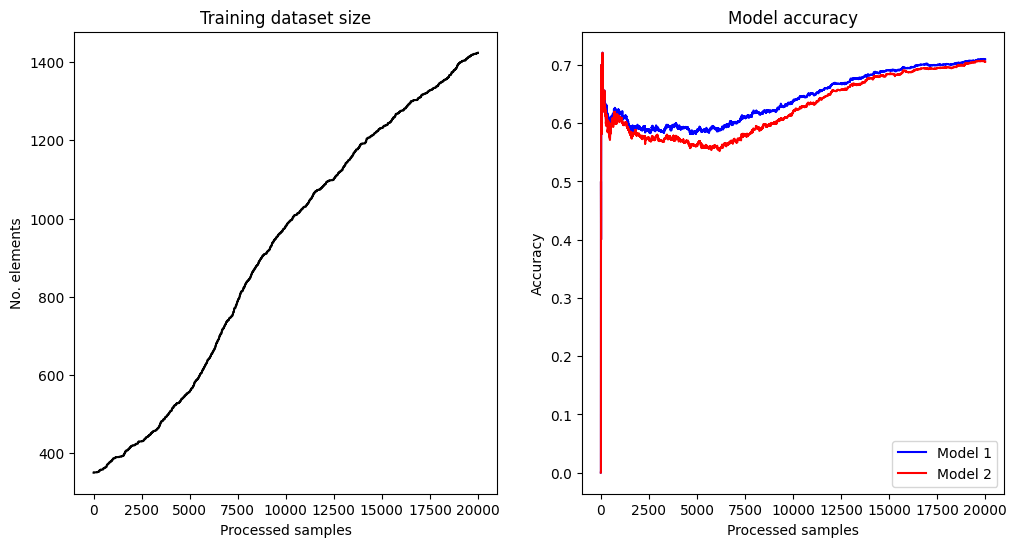

In [276]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].plot(steps, trainset_size, color="black")
ax[0].set_xlabel("Processed samples")
ax[0].set_ylabel("No. elements")
ax[0].set_title("Training dataset size")

ax[1].plot(steps, accuracy1, color="blue", label = "Model 1")
ax[1].plot(steps, accuracy2, color="red", label = "Model 2")
ax[1].set_xlabel("Processed samples")
ax[1].set_ylabel("Accuracy")
ax[1].set_title("Model accuracy")
ax[1].legend()

plt.show()


Początkowo obserwujemy pewną niestabilność modelu, dodawanie do zbioru treningowego trudnych do klasyfikacji próbek, być może niepasujących do poprzednio wyuczonych wzorów, początkowo obniża skuteczność modelu. Niemniej, po pewnym czasie, gdy liczba próbek w zbiorze treningowym wzrasta, dokładność modelu w klasyfikacji już przeprocesowanych próbek zaczyna systematycznie wzrastać wraz ze wzrostem przeprocesowanych próbek.

## 6*. Use another model

Create another (third) model from the same version space and propose a way to utilize all 3 models in identification of the samples that should be labeled. Implement the proposed solution and compare the results with the previous approach.

In [ ]:
# write your code here

clf3 = RidgeClassifier(alpha=2)

#prepare the classifiers in initial states prepared with the same data
X_initial_scaled = scaler.fit_transform(X_initial)
clf.fit(X_initial_scaled, y_initial)
clf2.fit(X_initial_scaled, y_initial)
clf3.fit(X_initial_scaled, y_initial)


# Przygotowanie metryk
#N = 20000
steps = np.arange(N)   #kolejne numery iteracji
accuracy1 = np.zeros(N)
accuracy2 = np.zeros(N)
accuracy3 = np.zeros(N)
trainset_size = np.zeros(N)

accuracy1[0] = clf.score(scaler.transform(X_stream), y_stream)
accuracy2[0] = clf2.score(scaler.transform(X_stream), y_stream)
accuracy3[0] = clf3.score(scaler.transform(X_stream), y_stream)
trainset_size[0] = X_initial.shape[0]

processed_images = np.zeros((N, X_initial.shape[1]))
processed_labels = np.zeros(N)

#Pętla uczenia
for i in tqdm(range(N)):

    next_idx, next_image = next(gen)
    processed_images[i] = next_image
    processed_labels[i] = y[next_idx]

    # Skalowanie obrazu
    next_image_scaled = scaler.transform([next_image])[0]

    if clf.predict([next_image_scaled])[0] != clf2.predict([next_image_scaled])[0] or clf3.predict([next_image_scaled])[0] != clf2.predict([next_image_scaled])[0] or clf.predict([next_image_scaled])[0] != clf3.predict([next_image_scaled])[0]:

        # dodaj do zbioru treningowego
        X_initial = np.vstack([X_initial, next_image])
        y_initial = np.append(y_initial, y[next_idx])

        # przeskaluj ponownie
        X_initial_scaled = scaler.fit_transform(X_initial)
        
        # trenuj modele
        clf.fit(X_initial_scaled, y_initial)
        clf2.fit(X_initial_scaled, y_initial)
        clf3.fit(X_initial_scaled, y_initial)

        # zapis
        trainset_size[i] = X_initial.shape[0]
    elif i>0:   #jeżeli nic się nie zmieniło od poprzedniej iteracji
        trainset_size[i]= trainset_size[i-1]
    
    processed_images_scaled = scaler.transform(processed_images[:i+1, :])
    accuracy1[i] = clf.score(processed_images_scaled, processed_labels[:i+1])
    accuracy2[i] = clf2.score(processed_images_scaled, processed_labels[:i+1])
    accuracy3[i] = clf3.score(processed_images_scaled, processed_labels[:i+1])

print(trainset_size)
print(accuracy1)
print(accuracy2)
print(accuracy3)


100%|██████████| 20000/20000 [2:16:09<00:00,  2.45it/s]       

[1424. 1424. 1424. ... 2358. 2358. 2358.]
[1.         1.         1.         ... 0.78507851 0.78508925 0.7851    ]
[1.         1.         1.         ... 0.78217822 0.78218911 0.7822    ]
[1.         1.         1.         ... 0.78592859 0.7859393  0.78595   ]


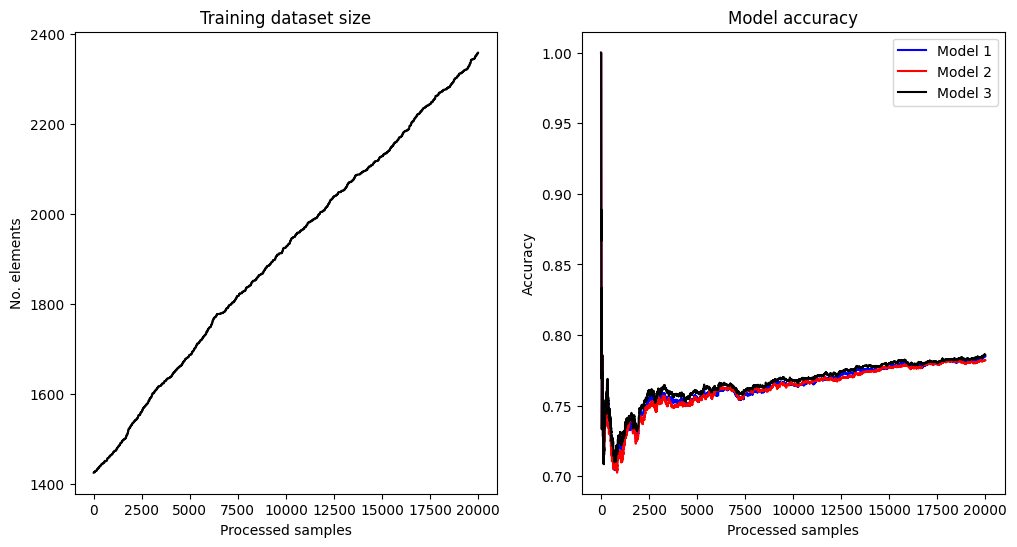

In [278]:
#Plot images
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].plot(steps, trainset_size, color="black")
ax[0].set_xlabel("Processed samples")
ax[0].set_ylabel("No. elements")
ax[0].set_title("Training dataset size")

ax[1].plot(steps, accuracy1, color="blue", label = "Model 1")
ax[1].plot(steps, accuracy2, color="red", label = "Model 2")
ax[1].plot(steps, accuracy3, color="black", label = "Model 3")
ax[1].set_xlabel("Processed samples")
ax[1].set_ylabel("Accuracy")
ax[1].set_title("Model accuracy")
ax[1].legend()
ax[1].legend()

plt.show()

W tym przypadku od początku startujemy z większym zbiorem treningowym, niż w przypadku analizowanym poprzednio (teraz zaczynamy z tym, z czym wcześniej kończyliśmy). Początkowo modele również wykazują krótki okres niestabilności, jednak znacznie szybciej niż poprzednio osiągaja dość stabilny poziom, od którego następuje stopniowy wzrost, równie szybki (a może nawet szybszy), niż w poprzednim przypadku.

## 7*. Implement a randomized strategy

Instead of using the models to identify the samples that should be labeled, implement a randomized strategy. Assume different probabilities when deciding which sample to label - make sure you include the probability consistent with QoC selection rate from Section 5. Compare the results with the previous approaches.

In [279]:
import random
if clf3 is None:
    clf3 = RidgeClassifier(alpha=2)


#prepare the classifiers in initial states prepared with the same data
X_initial_scaled = scaler.fit_transform(X_initial)
clf.fit(X_initial_scaled, y_initial)
clf2.fit(X_initial_scaled, y_initial)
clf3.fit(X_initial_scaled, y_initial)

p = np.average([accuracy1[-1], accuracy2[-1], accuracy3[-1]])

#prepare the classifiers in initial states prepared with the same data
X_initial_scaled = scaler.fit_transform(X_initial)
clf.fit(X_initial_scaled, y_initial)
clf2.fit(X_initial_scaled, y_initial)
clf3.fit(X_initial_scaled, y_initial)

# Przygotowanie metryk
N = 20000
steps = np.arange(N)   #kolejne numery iteracji
accuracy1 = np.zeros(N)
accuracy2 = np.zeros(N)
accuracy3 = np.zeros(N)
trainset_size = np.zeros(N)

accuracy1[0] = clf.score(scaler.transform(X_stream), y_stream)
accuracy2[0] = clf2.score(scaler.transform(X_stream), y_stream)
accuracy3[0] = clf3.score(scaler.transform(X_stream), y_stream)
trainset_size[0] = X_initial.shape[0]

processed_images = np.zeros((N, X_initial.shape[1]))
processed_labels = np.zeros(N)

#Pętla uczenia
for i in tqdm(range(N)):

    next_idx, next_image = next(gen)
    processed_images[i] = next_image
    processed_labels[i] = y[next_idx]

    # Skalowanie obrazu
    next_image_scaled = scaler.transform([next_image])[0]

    if random.random()<p:

        # dodaj do zbioru treningowego
        X_initial = np.vstack([X_initial, next_image])
        y_initial = np.append(y_initial, y[next_idx])

        # przeskaluj ponownie
        X_initial_scaled = scaler.fit_transform(X_initial)
        
        # trenuj modele
        clf.fit(X_initial_scaled, y_initial)
        clf2.fit(X_initial_scaled, y_initial)
        clf3.fit(X_initial_scaled, y_initial)

    # zapis
    trainset_size[i] = X_initial.shape[0]
    
    processed_images_scaled = scaler.transform(processed_images[:i+1, :])
    accuracy1[i] = clf.score(processed_images_scaled, processed_labels[:i+1])
    accuracy2[i] = clf2.score(processed_images_scaled, processed_labels[:i+1])
    accuracy3[i] = clf3.score(processed_images_scaled, processed_labels[:i+1])

print(trainset_size)
print(accuracy1)
print(accuracy2)
print(accuracy3)


100%|██████████| 20000/20000 [4:30:20<00:00,  1.23it/s]      

[ 2359.  2360.  2361. ... 18014. 18015. 18016.]
[1.         1.         1.         ... 0.83828383 0.83824191 0.8383    ]
[1.         1.         1.         ... 0.83853385 0.83849192 0.83855   ]
[1.         1.         1.         ... 0.83828383 0.83834192 0.83835   ]


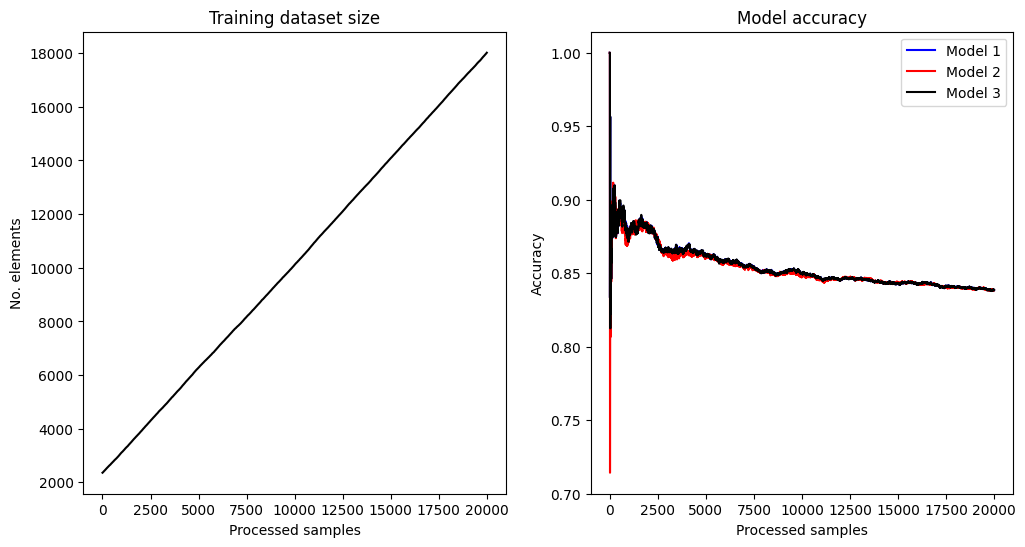

In [282]:
#Plot images
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].plot(steps, trainset_size, color="black")
ax[0].set_xlabel("Processed samples")
ax[0].set_ylabel("No. elements")
ax[0].set_title("Training dataset size")

ax[1].plot(steps, accuracy1, color="blue", label = "Model 1")
ax[1].plot(steps, accuracy2, color="red", label = "Model 2")
ax[1].plot(steps, accuracy3, color="black", label = "Model 3")
ax[1].set_xlabel("Processed samples")
ax[1].set_ylabel("Accuracy")
ax[1].set_title("Model accuracy")
ax[1].legend()
ax[1].legend()
plt.show()


Najciekawszy przypadek obserwujemy w tym przypadku. Modele poczatkowo startują od stosunkowo najlepszej skuteczności, jednak wraz ze wzrostem liczby przeprocesowanych próbek, gdy próbki dodawane do zbioru treningowego są dodawane losowo, skuteczność wszystkich modeli na zbiorze już przeprocesowanych próbek (w tej pętli algorytmu) zaczyna maleć. Może to oznaczać, że próbki poprzednio dodawane do zbioru treningowego (gdy klasyfikatory nie były zgodne), były w jakiś sposób szczególne i nie oddawały dokładnie tego samego rozkładu cech, co w zbiorze próbek wybieranych losowo. Zmiana sposobu wyboru przypadków do klasyfikacji sprawia, że modele dostaja do uczenia innego rodzaju dane, co prowadzi do zmiany ich parametrów, zaburzając ich funkcjonowanie.